In [ ]:
import zipfile
import os

# Define the path to your zip file
# If you uploaded directly to Colab session storage:
zip_file_path = '/content/fake news detection (1).zip' # <--- Make sure this matches your uploaded zip file name!

# If your zip file is in Google Drive (e.g., in a folder named 'FakeNewsProject'):
# zip_file_path = '/content/drive/My Drive/FakeNewsProject/fake-news.zip'

# Define the directory where you want to extract the files
extraction_path = '/content/fake_news_data/' # This will create a new folder for your CSVs

# Create the extraction directory if it doesn't exist
if not os.path.exists(extraction_path):
    os.makedirs(extraction_path)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Files extracted to: {extraction_path}")
print(f"Contents of extraction path: {os.listdir(extraction_path)}")

Files extracted to: /content/fake_news_data/
Contents of extraction path: ['News _dataset']


In [ ]:
import pandas as pd

# Load the datasets from the extraction path
true_news = pd.read_csv(os.path.join(extraction_path, '/content/fake_news_data/News _dataset/True.csv'))
fake_news = pd.read_csv(os.path.join(extraction_path, '/content/fake_news_data/News _dataset/Fake.csv'))

# Add a 'label' column to differentiate real and fake news
true_news['label'] = 0 # 0 for real news
fake_news['label'] = 1 # 1 for fake news

# Combine the datasets into a single DataFrame
# We'll focus on the 'text' and 'label' columns for this project
df = pd.concat([true_news[['text', 'label']], fake_news[['text', 'label']]], ignore_index=True)

# Shuffle the combined DataFrame to mix real and fake news articles
# This is crucial for unbiased training and testing
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the first few rows and basic info to confirm everything loaded correctly
print("--- Combined DataFrame Head ---")
print(df.head())

print("\n--- DataFrame Info ---")
print(df.info())

print("\n--- Label Distribution ---")
print(df['label'].value_counts())

--- Combined DataFrame Head ---
                                                text  label
0  Donald Trump s White House is in chaos, and th...      1
1  Now that Donald Trump is the presumptive GOP n...      1
2  Mike Pence is a huge homophobe. He supports ex...      1
3  SAN FRANCISCO (Reuters) - California Attorney ...      0
4  Twisted reasoning is all that comes from Pelos...      1

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB
None

--- Label Distribution ---
label
1    23481
0    21417
Name: count, dtype: int64


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# --- CORRECTED NLTK Resource Downloads ---
# Download NLTK resources (only need to run these once)
try:
    nltk.data.find('corpora/stopwords')
except LookupError: # Corrected: Use LookupError
    print("Downloading 'stopwords' corpus...")
    nltk.download('stopwords')
    print("'stopwords' downloaded.")

try:
    nltk.data.find('tokenizers/punkt')
except LookupError: # Corrected: Use LookupError
    print("Downloading 'punkt' tokenizer...")
    nltk.download('punkt')
    print("'punkt' downloaded.")
# --- END CORRECTED NLTK Resource Downloads ---


# Initialize the Porter Stemmer and load English stop words
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Define the preprocessing function
def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove punctuation and numbers
    # This regex keeps only lowercase letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Simple Tokenization (split into words)
    words = text.split()

    # 4. Remove Stop Words
    words = [word for word in words if word not in stop_words]

    # 5. Stemming
    words = [ps.stem(word) for word in words]

    # Join words back into a single string
    return ' '.join(words)

# Apply the preprocessing function to the 'text' column of your DataFrame
# We'll store the cleaned text in a new column called 'processed_text'
df['processed_text'] = df['text'].apply(preprocess_text)

# Display the first few rows of the DataFrame with the new processed_text column
print("--- DataFrame with Processed Text ---")
print(df[['text', 'processed_text', 'label']].head())

# You can also pick a random article to see its raw vs processed text
print("\n--- Example of Raw vs. Processed Text ---")
sample_index = 123 # You can change this index to view different examples
print(f"Original Text (Index {sample_index}):\n{df['text'].iloc[sample_index][:300]}...") # Display first 300 chars
print(f"\nProcessed Text (Index {sample_index}):\n{df['processed_text'].iloc[sample_index][:300]}...")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...


'stopwords' downloaded.


[nltk_data]   Unzipping tokenizers/punkt.zip.


'punkt' downloaded.
--- DataFrame with Processed Text ---
                                                text  \
0  Donald Trump s White House is in chaos, and th...   
1  Now that Donald Trump is the presumptive GOP n...   
2  Mike Pence is a huge homophobe. He supports ex...   
3  SAN FRANCISCO (Reuters) - California Attorney ...   
4  Twisted reasoning is all that comes from Pelos...   

                                      processed_text  label  
0  donald trump white hous chao tri cover russia ...      1  
1  donald trump presumpt gop nomine time rememb c...      1  
2  mike penc huge homophob support exgay convers ...      1  
3  san francisco reuter california attorney gener...      0  
4  twist reason come pelosi day especi promin dem...      1  

--- Example of Raw vs. Processed Text ---
Original Text (Index 123):
Karma It seems to be biting a lot of anti-Trump libs pretty hard in the a*s lately A movie is in the works about Hillary Clinton and her amazing  criminal life, an

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Define our features (X) and target (y)
# X will be the processed text, and y will be the label (0 for real, 1 for fake)
X = df['processed_text']
y = df['label']

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state=42 ensures reproducibility (you get the same split every time)
# stratify=y ensures that the proportion of real/fake news is consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize TfidfVectorizer
# max_features=5000 means it will consider the top 5000 most important words
# This helps reduce dimensionality and noise for a beginner project
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer on the training data and transform it
# X_train_tfidf will now contain numerical TF-IDF representations of your training articles
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data using the *same* vectorizer fitted on the training data
# X_test_tfidf will contain numerical TF-IDF representations of your testing articles
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nShape of X_train_tfidf (features for training): {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf (features for testing): {X_test_tfidf.shape}")

# Optionally, you can inspect some of the feature names (words) learned by TF-IDF
# print("\nSome example TF-IDF feature names:")
# print(tfidf_vectorizer.get_feature_names_out()[:50])

Shape of X_train: (35918,)
Shape of X_test: (8980,)
Shape of y_train: (35918,)
Shape of y_test: (8980,)

Shape of X_train_tfidf (features for training): (35918, 5000)
Shape of X_test_tfidf (features for testing): (8980, 5000)


--- Training Multinomial Naive Bayes Model ---
Multinomial Naive Bayes Performance:
Accuracy: 0.9273
Precision: 0.9197
Recall: 0.9434
F1-score: 0.9314


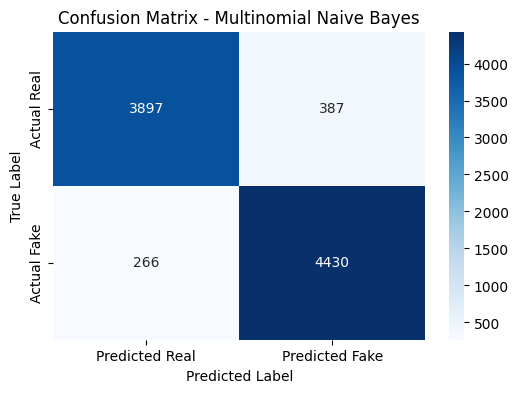



--- Training Logistic Regression Model ---
Logistic Regression Performance:
Accuracy: 0.9873
Precision: 0.9883
Recall: 0.9874
F1-score: 0.9879


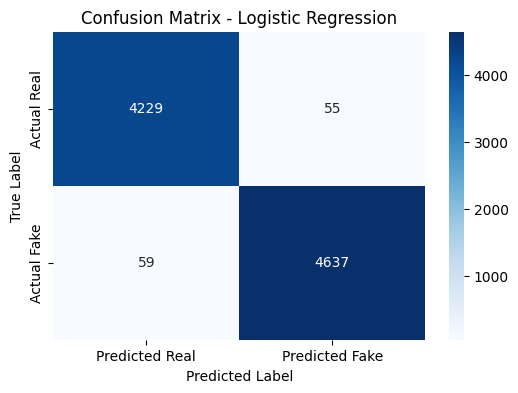



--- Training Support Vector Machine Model ---
Support Vector Machine Performance:
Accuracy: 0.9937
Precision: 0.9957
Recall: 0.9921
F1-score: 0.9939


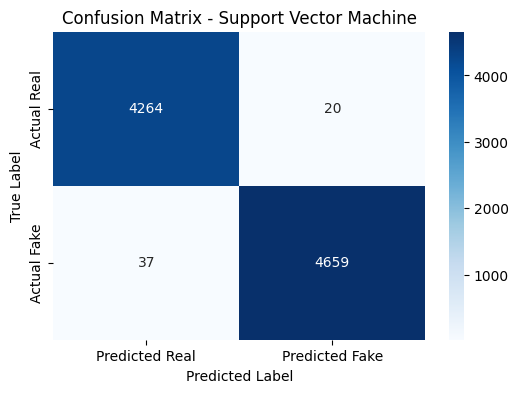

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Multinomial Naive Bayes ---
print("--- Training Multinomial Naive Bayes Model ---")
mnb_model = MultinomialNB()
mnb_model.fit(X_train_tfidf, y_train)
y_pred_mnb = mnb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mnb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_mnb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_mnb):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_mnb):.4f}")

# Confusion Matrix for MNB
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Real', 'Predicted Fake'], yticklabels=['Actual Real', 'Actual Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.show()

print("\n" + "="*50 + "\n") # Separator for clarity

# --- 2. Logistic Regression ---
print("--- Training Logistic Regression Model ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_lr):.4f}")

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Real', 'Predicted Fake'], yticklabels=['Actual Real', 'Actual Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print("\n" + "="*50 + "\n") # Separator for clarity

# --- 3. Support Vector Machine (Linear Kernel for speed) ---
print("--- Training Support Vector Machine Model ---")
# Using a linear kernel is often efficient for text data with many features
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("Support Vector Machine Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_svm):.4f}")

# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Real', 'Predicted Fake'], yticklabels=['Actual Real', 'Actual Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Support Vector Machine')
plt.show()

print("\n" + "="*50 + "\n") # Separator for clarity

In [ ]:
# Ensure you've run the Logistic Regression training code from the previous step
# If not, please go back and run that cell first to make sure lr_model is trained.

# Get the feature names (words) from your TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get the coefficients from the trained Logistic Regression model
# lr_model.coef_[0] because it's a binary classification, so it has one set of coefficients
coefs = lr_model.coef_[0]

# Create a list of (coefficient, feature_name) pairs
feature_coefs = sorted(zip(coefs, feature_names), reverse=True) # Sort in descending order of coefficient

print("--- Top 15 Words Strongly Indicating FAKE News ---")
for i, (coef, feature) in enumerate(feature_coefs[:15]):
    print(f"{i+1}. {feature}: {coef:.4f}")

print("\n--- Top 15 Words Strongly Indicating REAL News ---")
# Get the words with the smallest (most negative) coefficients
for i, (coef, feature) in enumerate(feature_coefs[-15:]):
    print(f"{i+1}. {feature}: {coef:.4f}")

--- Top 15 Words Strongly Indicating FAKE News ---
1. via: 8.7786
2. imag: 6.9566
3. gop: 4.9155
4. mr: 4.8358
5. wire: 4.5857
6. american: 4.5025
7. hillari: 4.4842
8. even: 4.1911
9. america: 3.8388
10. obama: 3.7791
11. rep: 3.7621
12. sen: 3.4753
13. like: 3.4539
14. know: 3.3471
15. daili: 3.2041

--- Top 15 Words Strongly Indicating REAL News ---
1. statement: -3.6460
2. minist: -3.6594
3. edt: -3.8006
4. nov: -4.1405
5. im: -4.1427
6. monday: -4.2932
7. us: -4.5076
8. dont: -4.5770
9. friday: -4.7492
10. thursday: -4.9192
11. tuesday: -5.2537
12. wednesday: -5.5136
13. washington: -5.9063
14. said: -18.1952
15. reuter: -27.5479
